# 🌎 Regional Analysis

Geographical analysis helps identify high-performing and underperforming regions.

This section answers:

- Which region generates the highest revenue?
- Which region generates the highest profit?
- Which states should receive more investment?
- Which states require business attention?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_csv('../data/Superstore.csv', encoding="latin1")

In [3]:
region_summary = (

    df.groupby("Region")

    .agg(

        Total_Sales=("Sales","sum"),

        Total_Profit=("Profit","sum"),

        Orders=("Order ID","nunique"),

        Customers=("Customer ID","nunique"),

        Avg_Discount=("Discount","mean")

    )

    .sort_values(

        by="Total_Sales",

        ascending=False

    )

)

region_summary

,Total_Sales,Total_Profit,Orders,Customers,Avg_Discount
Region,,,,,
West,725457.8245,108418.4489,1611,686,0.109335
East,678781.2400,91522.7800,1401,674,0.145365
Central,501239.8908,39706.3625,1175,629,0.240353
South,391721.9050,46749.4303,822,512,0.147253


In [4]:
region_summary.style.format({

    "Total_Sales":"${:,.2f}",

    "Total_Profit":"${:,.2f}",

    "Avg_Discount":"{:.2%}"

}).background_gradient(cmap="YlGn")

,Total_Sales,Total_Profit,Orders,Customers,Avg_Discount
Region,,,,,
West,"$725,457.82","$108,418.45",1611,686,10.93%
East,"$678,781.24","$91,522.78",1401,674,14.54%
Central,"$501,239.89","$39,706.36",1175,629,24.04%
South,"$391,721.91","$46,749.43",822,512,14.73%


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


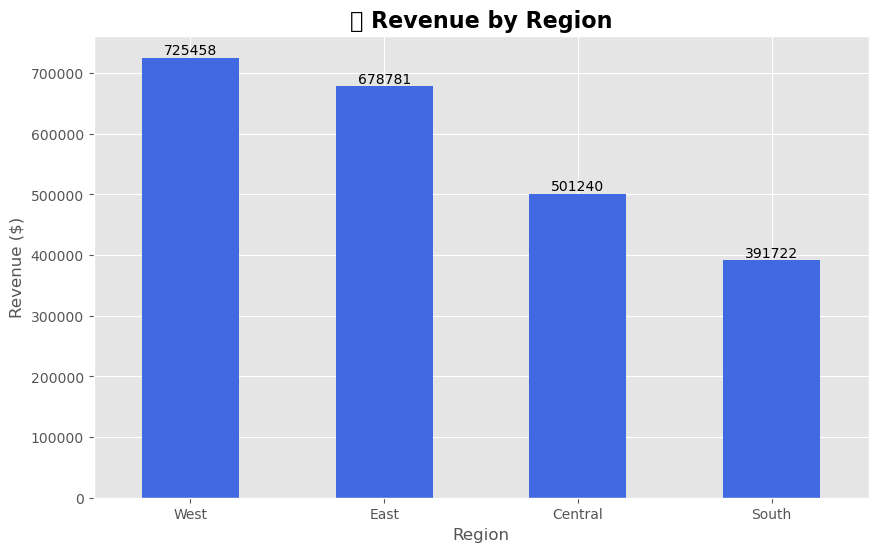

In [5]:
ax=(

region_summary

["Total_Sales"]

.plot(

kind="bar",

figsize=(10,6),

color="royalblue"

)

)

plt.title(

"🌎 Revenue by Region",

fontsize=16,

fontweight="bold"

)

plt.xlabel("Region")

plt.ylabel("Revenue ($)")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

## 📌 Observation

The highest revenue-generating region contributes a significant share of the company's overall sales.

Understanding why this region performs well can help replicate successful strategies in other regions.

C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


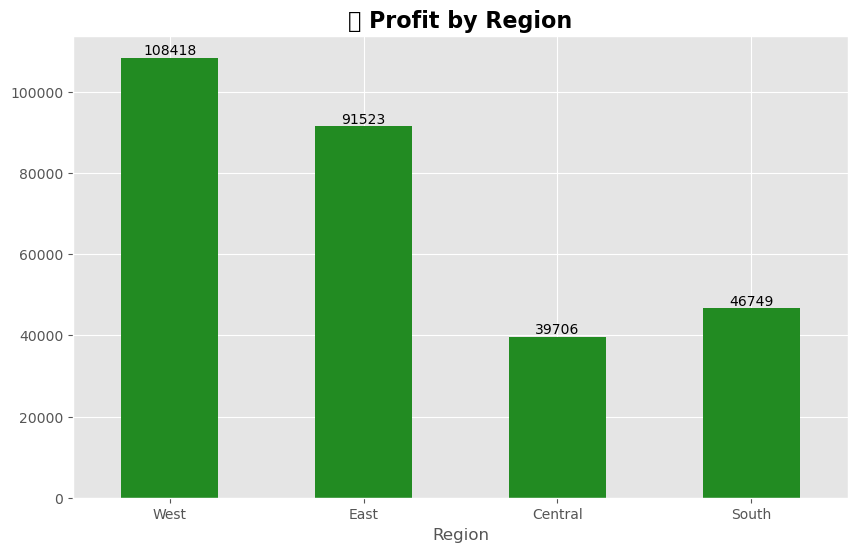

In [6]:
ax=(

region_summary

["Total_Profit"]

.plot(

kind="bar",

figsize=(10,6),

color="forestgreen"

)

)

plt.title(

"💰 Profit by Region",

fontsize=16,

fontweight="bold"

)

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()


In [7]:
state_summary=(

df.groupby("State")

.agg(

Revenue=("Sales","sum"),

Profit=("Profit","sum"),

Orders=("Order ID","nunique"),

Customers=("Customer ID","nunique")

)

.sort_values(

"Revenue",

ascending=False

)

)

state_summary.head()

,Revenue,Profit,Orders,Customers
State,,,,
California,457687.6315,76381.3871,1021,577
New York,310876.2710,74038.5486,562,415
Texas,170188.0458,-25729.3563,487,370
Washington,138641.2700,33402.6517,256,224
Pennsylvania,116511.9140,-15559.9603,288,257


In [8]:
state_summary.style.format({

"Revenue":"${:,.2f}",

"Profit":"${:,.2f}"

}).background_gradient(cmap="coolwarm")

,Revenue,Profit,Orders,Customers
State,,,,
California,"$457,687.63","$76,381.39",1021,577
New York,"$310,876.27","$74,038.55",562,415
Texas,"$170,188.05","$-25,729.36",487,370
Washington,"$138,641.27","$33,402.65",256,224
Pennsylvania,"$116,511.91","$-15,559.96",288,257
Florida,"$89,473.71","$-3,399.30",200,181
Illinois,"$80,166.10","$-12,607.89",276,237
Ohio,"$78,258.14","$-16,971.38",236,202
Michigan,"$76,269.61","$24,463.19",117,106


In [9]:
top_states=(

state_summary

.nlargest(

10,

"Revenue"

)

)

top_states

,Revenue,Profit,Orders,Customers
State,,,,
California,457687.6315,76381.3871,1021,577
New York,310876.2710,74038.5486,562,415
Texas,170188.0458,-25729.3563,487,370
Washington,138641.2700,33402.6517,256,224
Pennsylvania,116511.9140,-15559.9603,288,257
Florida,89473.7080,-3399.3017,200,181
Illinois,80166.1010,-12607.8870,276,237
Ohio,78258.1360,-16971.3766,236,202
Michigan,76269.6140,24463.1876,117,106


In [10]:
top_states=(

state_summary

.nlargest(

10,

"Revenue"

)

)

top_states

,Revenue,Profit,Orders,Customers
State,,,,
California,457687.6315,76381.3871,1021,577
New York,310876.2710,74038.5486,562,415
Texas,170188.0458,-25729.3563,487,370
Washington,138641.2700,33402.6517,256,224
Pennsylvania,116511.9140,-15559.9603,288,257
Florida,89473.7080,-3399.3017,200,181
Illinois,80166.1010,-12607.8870,276,237
Ohio,78258.1360,-16971.3766,236,202
Michigan,76269.6140,24463.1876,117,106


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


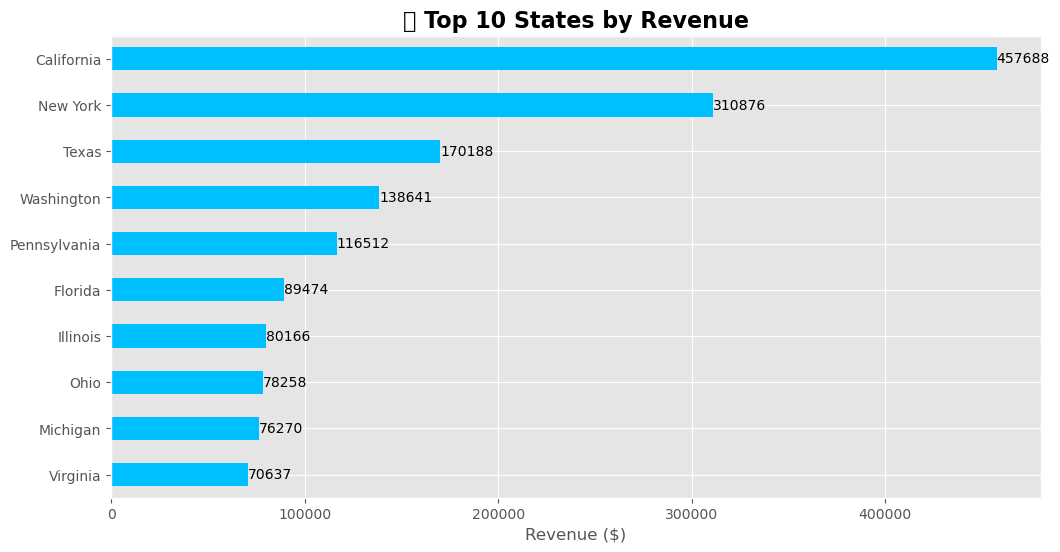

In [11]:
ax=(

top_states

.sort_values("Revenue")

["Revenue"]

.plot(

kind="barh",

figsize=(12,6),

color="deepskyblue"

)

)

plt.title(

"🏆 Top 10 States by Revenue",

fontsize=16,

fontweight="bold"

)

plt.xlabel("Revenue ($)")

plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

In [12]:
top_profit_states=(

state_summary

.nlargest(

10,

"Profit"

)

)

top_profit_states

,Revenue,Profit,Orders,Customers
State,,,,
California,457687.6315,76381.3871,1021,577
New York,310876.2710,74038.5486,562,415
Washington,138641.2700,33402.6517,256,224
Michigan,76269.6140,24463.1876,117,106
Virginia,70636.7200,18597.9504,115,107
Indiana,53555.3600,18382.9363,73,70
Georgia,49095.8400,16250.0433,91,83
Kentucky,36591.7500,11199.6966,61,58
Minnesota,29863.1500,10823.1874,44,42


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


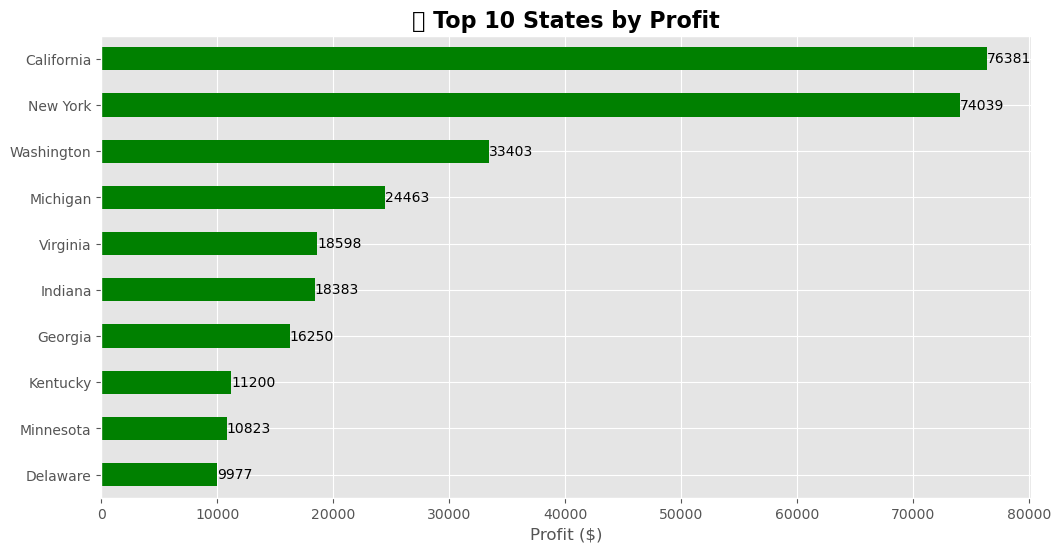

In [13]:
ax=(

top_profit_states

.sort_values("Profit")

["Profit"]

.plot(

kind="barh",

figsize=(12,6),

color="green"

)

)

plt.title(

"💰 Top 10 States by Profit",

fontsize=16,

fontweight="bold"

)

plt.xlabel("Profit ($)")

plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

In [14]:
loss_states=(

state_summary

.nsmallest(

10,

"Profit"

)

)

loss_states

,Revenue,Profit,Orders,Customers
State,,,,
Texas,170188.0458,-25729.3563,487,370
Ohio,78258.1360,-16971.3766,236,202
Pennsylvania,116511.9140,-15559.9603,288,257
Illinois,80166.1010,-12607.8870,276,237
North Carolina,55603.1640,-7490.9122,136,122
Colorado,32108.1180,-6527.8579,79,75
Tennessee,30661.8730,-5341.6936,91,84
Arizona,35282.0010,-3427.9246,108,100
Florida,89473.7080,-3399.3017,200,181


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


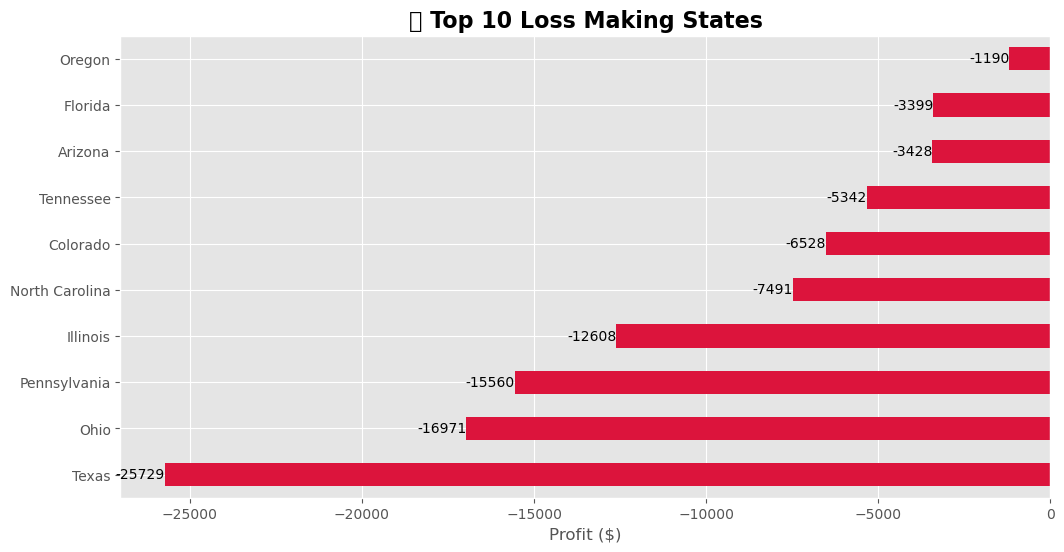

In [15]:
ax=(

loss_states

["Profit"]

.plot(

kind="barh",

figsize=(12,6),

color="crimson"

)

)

plt.title(

"📉 Top 10 Loss Making States",

fontsize=16,

fontweight="bold"

)

plt.xlabel("Profit ($)")

plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

In [16]:
state_summary["Performance"] = np.where(
    state_summary["Profit"] > 0,
    "🟢 Profitable",
    "🔴 Loss"
)

state_summary.head(10)

,Revenue,Profit,Orders,Customers,Performance
State,,,,,
California,457687.6315,76381.3871,1021,577,🟢 Profitable
New York,310876.2710,74038.5486,562,415,🟢 Profitable
Texas,170188.0458,-25729.3563,487,370,🔴 Loss
Washington,138641.2700,33402.6517,256,224,🟢 Profitable
Pennsylvania,116511.9140,-15559.9603,288,257,🔴 Loss
Florida,89473.7080,-3399.3017,200,181,🔴 Loss
Illinois,80166.1010,-12607.8870,276,237,🔴 Loss
Ohio,78258.1360,-16971.3766,236,202,🔴 Loss
Michigan,76269.6140,24463.1876,117,106,🟢 Profitable


# ✅ Regional Analysis Conclusion

### Key Findings

- Revenue and profit vary significantly across regions and states.
- A small number of states contribute a large share of total business performance.
- Some states generate strong sales but weak profitability, indicating possible pricing or discount issues.
- Loss-making states should be investigated to identify operational improvements.

### Business Recommendation

- Invest more in high-performing states.
- Review pricing and discount strategies in low-profit regions.
- Analyze product mix in loss-making states to improve margins.